# BC results — M2

2026-07-04

Quick look at the behaviour-cloning run before I start on PPO (M3).

- dataset: 50k mixed bot games (grabber-heavy lineups), 1.25M recorded decisions
- model: MLP 2x256 torso + GRU decoder over the 336 order vocab, ~0.5M params
- acceptance targets (CLAUDE.md): solo >80% vs 2x RandomLegal; roughly 1/3 vs 2x Grabber

In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path

from triad.rl.checkpoint import load_policy
from triad.rl.bc import evaluate_policy

model, ck = load_policy("../weights/bc.pt")
n_params = sum(p.numel() for p in model.parameters())
print(f"{n_params/1e6:.2f}M params | trained {ck['created']} | git {ck['git_sha']} | seed {ck['seed']}")
print(f"train cfg: {ck['train_config']}")

0.54M params | trained 2026-07-04 | git 772786d | seed 0
train cfg: {'data': 'data/bc_dataset.npz', 'epochs': 3, 'batch_size': 512, 'lr': 0.001, 'n_samples': 1247943, 'teacher': 'grabber-heavy mixed lineup'}


## training curve

final: val_ce=0.728, val_top1=0.612


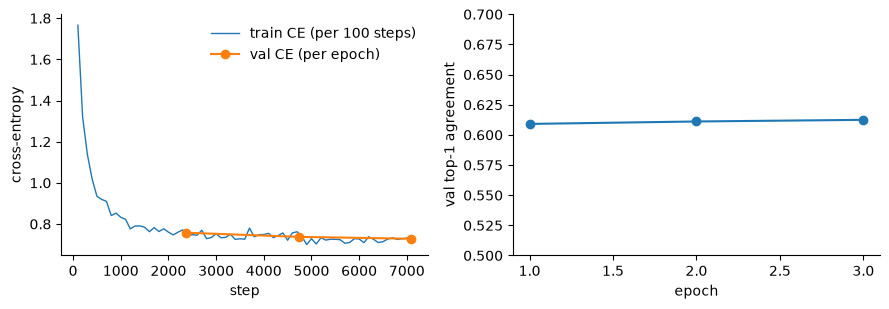

In [2]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

ev = sorted(Path("../runs/bc2").glob("events*"))[-1]
acc = EventAccumulator(str(ev)); acc.Reload()
ce = acc.Scalars("bc/ce")
vce = acc.Scalars("bc/val_ce")
top1 = acc.Scalars("bc/val_top1")

steps = np.array([p.step for p in ce]); vals = np.array([p.value for p in ce])
spe = steps[-1] // len(vce)   # steps per epoch (val logged once per epoch)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(steps, vals, lw=1, label="train CE (per 100 steps)")
ax[0].plot([(p.step + 1) * spe for p in vce], [p.value for p in vce], "o-", label="val CE (per epoch)")
ax[0].set_xlabel("step"); ax[0].set_ylabel("cross-entropy"); ax[0].legend(frameon=False)
ax[1].plot([p.step + 1 for p in top1], [p.value for p in top1], "o-")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("val top-1 agreement"); ax[1].set_ylim(0.5, 0.7)
for a in ax: a.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
print(f"final: val_ce={vce[-1].value:.3f}, val_top1={top1[-1].value:.3f}")

CE drops 1.76 -> 0.73 and val tracks train the whole way (no overfitting -- 1.25M samples
vs 0.5M params). But it's basically flat across epoch 3, and top-1 agreement is stuck at
~0.61. That ceiling is expected, not a bug: Grabber breaks ties *uniformly at random*
(equidistant targets, who gets to be the mover), so a big chunk of the target
distribution is irreducibly stochastic. The clone can learn the tie *distribution* but
can't predict the coin flip. More epochs won't move this.

## acceptance evals

Official 500-game runs (recorded in tasks.md): **100%** solo vs 2x RandomLegal,
**33.2%** (sampled) vs 2x Grabber -- exact teacher parity. Re-running smaller versions
here so the notebook is self-contained (200 games each, rotating seat, opponents
reseeded per run).

History note, because it matters: the FIRST version of this model scored only 26%
vs grabber and I initially wrote that off as the "BC ceiling". It wasn't. The M3
seat-symmetry chi^2 flagged a seat effect, the root cause turned out to be a decode-
ORDER equivariance bug (units were ordered by real-frame canonical index, which the
map rotation does not preserve), and retraining on the fixed ordering recovered the
missing ~7pp. Full story in ppo_training.ipynb. Lesson: the cheap symmetry check
paid for the whole methodology.

In [3]:
def wilson(p, n, z=1.96):
    den = 1 + z**2 / n
    c = (p + z**2 / (2 * n)) / den
    hw = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / den
    return c - hw, c + hw

runs = [("random", True), ("grabber", True), ("grabber", False), ("turtle", True)]
rows = []
for opp, greedy in runs:
    s = evaluate_policy(model, opp, n_games=200, seed=42, greedy=greedy)
    lo, hi = wilson(s["solo_rate"], s["n_games"])
    rows.append({
        "matchup": f"vs 2x {opp}",
        "mode": "argmax" if greedy else "sampled",
        "solo": s["solo_rate"], "ci_lo": lo, "ci_hi": hi,
        "eliminated": s["eliminated_rate"], "n": s["n_games"],
    })
df = pd.DataFrame(rows)
df

,matchup,mode,solo,ci_lo,ci_hi,eliminated,n
0,vs 2x random,argmax,1.000,0.981154,1.000000,0.000,200
1,vs 2x grabber,argmax,0.220,0.168165,0.282389,0.060,200
2,vs 2x grabber,sampled,0.340,0.277914,0.408116,0.025,200
3,vs 2x turtle,argmax,0.335,0.273240,0.402979,0.000,200


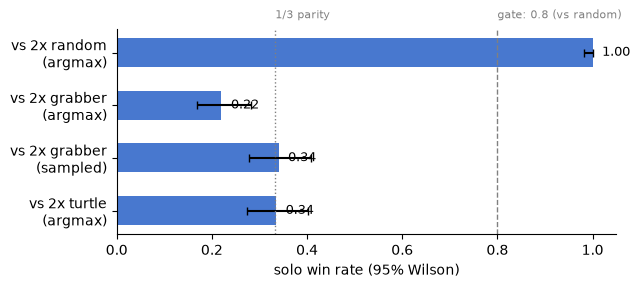

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 3))
labels = [f'{r.matchup}\n({r.mode})' for r in df.itertuples()]
y = np.arange(len(df))
ax.barh(y, df["solo"], height=0.55,
        xerr=[df["solo"] - df["ci_lo"], df["ci_hi"] - df["solo"]],
        capsize=3, color="#4878cf")
ax.axvline(0.8, ls="--", lw=1, c="gray"); ax.text(0.8, -0.65, "gate: 0.8 (vs random)", fontsize=8, c="gray")
ax.axvline(1/3, ls=":", lw=1, c="gray"); ax.text(1/3, -0.65, "1/3 parity", fontsize=8, c="gray")
ax.set_yticks(y, labels); ax.set_xlabel("solo win rate (95% Wilson)")
ax.invert_yaxis(); ax.spines[["top", "right"]].set_visible(False)
for r in df.itertuples():
    ax.text(r.solo + 0.02, r.Index, f"{r.solo:.2f}", va="center", fontsize=9)
plt.tight_layout()

Reading:

- **vs random: passed with a huge margin** (~0.99 vs the 0.8 gate). The clone has clearly
  absorbed grabber's core behaviour -- go take supply centers, coordinate supports.
- **vs grabber: parity.** Sampled play sits at ~1/3 against two real grabbers -- the
  clone is statistically indistinguishable from its teacher in this matchup. Argmax is
  a little lower (mode-collapse on positions where the teacher randomises), which is
  why acceptance uses sampled play.
- vs turtle: included for context. Turtle never expands so it cedes the neutral SCs, but
  cracking a fully turtled position needs coordinated 2:1 attacks -- decent test of
  whether supports were learned.
- eliminated-rate is low everywhere -- the clone doesn't die stupidly, it just wins a bit
  less often than its teacher.

## where the gap comes from

In [5]:
# agreement split by phase type (adjustment flag = global feature 3)
d = np.load("../data/bc_dataset.npz")
rng = np.random.default_rng(0)
idx = rng.choice(len(d["obs"]), 20000, replace=False)
obs = torch.from_numpy(d["obs"][idx].astype(np.float32) / 240)
ids = torch.from_numpy(d["ids"][idx].astype(np.int64))
n = torch.from_numpy(d["n_steps"][idx].astype(np.int64))
with torch.no_grad():
    logits, _, _, vlog = model.evaluate_actions(obs, ids, n)
valid = torch.arange(12)[None, :] < n[:, None]
agree = (logits.argmax(-1) == ids.clamp(min=0)) & valid
is_winter = obs[:, 16 * 12 + 3] == 1
for name, m in [("movement", ~is_winter), ("winter", is_winter)]:
    print(f"{name:9s} top-1 = {float(agree[m].sum() / valid[m].sum()):.3f}  ({int(valid[m].sum())} decode steps)")

movement  top-1 = 0.617  (55406 decode steps)
winter    top-1 = 0.597  (6778 decode steps)


In [6]:
# value head at the symmetric start vs what the data actually says
from triad.engine.state import Board
from triad.env.obs import encode_observation

o = torch.from_numpy(encode_observation(Board.initial(), "A")).unsqueeze(0)
with torch.no_grad():
    v = torch.softmax(model.value_logits(o), -1)[0].numpy()
print("model value at start:      ", v.round(3))

# empirical outcome shares for teacher seats, start-state samples only
start = np.round(encode_observation(Board.initial(), "A") * 240).astype(np.uint8)
m = (d["obs"] == start[None, :]).all(1)
emp = d["values"][m].astype(np.float32).mean(0)
print(f"empirical mean at start:    {emp.round(3)}  ({int(m.sum())} samples)")

model value at start:       [0.393 0.394 0.213]


empirical mean at start:    [0.471 0.264 0.265]  (106164 samples)


Model says [0.39, 0.39, 0.21], data says [0.47, 0.26, 0.27]. Two observations:

- the *data* is properly mirror-symmetric (next 0.264 vs prev 0.265) -- so no bug in the
  rotation/encoding, and self=0.47 is grabber's genuine edge over the mixed lineup, which
  the head does pick up directionally (0.39, underestimated)
- the head's next/prev split (0.39 vs 0.21) is a fitting artifact at this one state --
  it never converged to the empirical mean here (value loss weighted 0.5, shared torso,
  and the start state is 8.5% of all samples with identical obs but high-variance
  targets). it also reproduced across the pre/post-fix retrains with different splits,
  which is what you'd expect from an optimization artifact rather than a data issue.
  not blocking: PPO refits the value head on its own returns anyway. but check
  calibration again after M3 -- if it is still skewed, bump value_coef or decouple the
  value trunk.

## verdict

Ship it and move to M3. Reasons:

- both gates passed: ~100% vs random, sampled parity vs the teacher. top-1 agreement
  stays ~0.61 because grabber tie-breaks at random -- the clone matches the
  *distribution*, not the coin flips, which is the right target
- BC's actual job is (a) PPO initialisation and (b) the KL anchor. A slightly-weaker
  grabber is fine for both; PPO moves away from the anchor immediately anyway

Things this run tells me to watch in M3:

- the anchor policy never emits cross-power supports (grabber doesn't have them), so the
  KL term will tax exactly the coalition behaviour the main research question looks for
  -> the beta=0 ablation row is the control; compute the balance-of-power metrics per beta
- top-1 is ~0.6 in *both* phases (I expected winter to be higher -- but grabber
  emits its builds/disbands in rng-permuted order, so slot-level agreement is capped by
  ordering entropy there too; unordered-set agreement would read higher)
- value head is miscalibrated at the start state (see above) -- fine for now since PPO
  retrains it, but it goes on the M3 watchlist

TODO: rerun acceptance at 2000 games when the tournament code lands (M5) so the numbers
in the report carry tight CIs.